# 🌍 **ML Foundation Week 3: Country Clustering Analysis for NGO Aid Allocation** 🌍

### **Submitted By: Devratan**

This project applies unsupervised machine learning techniques to group countries based on socio-economic and health indicators. The objective is to identify vulnerable countries that may require priority support from NGOs and international aid organizations.

## 📌 **Project Objective** 📌

The primary objective of this project is to segment countries into meaningful clusters using machine learning techniques. By analyzing socio-economic and health indicators such as income, GDP per capita, child mortality, and life expectancy, the project aims to identify countries that may benefit most from international aid and developmental support.

---

## 📊 **Executive Summary** 📊

This project focuses on clustering countries based on their socio-economic and health indicators to support data-driven decision making for NGOs and international organizations.

### **Key Highlights**

- Cleaned and preprocessed country-level data
- Applied feature scaling using StandardScaler
- Identified optimal clusters using Elbow Method
- Validated clusters using Silhouette Analysis
- Implemented K-Means Clustering
- Compared results with DBSCAN clustering
- Applied PCA for dimensionality reduction and visualization
- Identified vulnerable countries requiring priority support

### **Outcome**

The analysis successfully grouped countries into meaningful development categories and highlighted countries that require focused intervention in healthcare, education, nutrition, and economic development.

---

## 📚 **Import Required Libraries** 📚

The following libraries are imported for data manipulation, visualization, clustering, dimensionality reduction, and model evaluation.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

print("Importing Libraries...\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

Importing Libraries...



## 📂 **Loading the Dataset** 📂

The Country Data dataset is loaded into a Pandas DataFrame for further analysis and clustering.

In [ ]:
df = pd.read_csv('Country-data.csv')
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 🔍 **Dataset Overview** 🔍

This section provides an overview of the dataset including dimensions, column information, data types, and descriptive statistics.

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:\n")
df.info()

print("\nDescribe:\n")
display(df.describe(include='all').round(2))

Shape: (167, 10)

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Describe:



,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
unique,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,NaN,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,NaN,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,NaN,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,NaN,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,NaN,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00


## 🧹 **Data Cleaning & Quality Check** 🧹

Data quality checks are performed to identify missing values, duplicate records, and inconsistencies. Proper preprocessing ensures reliable clustering results.

In [ ]:
print("Missing Values:\n")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:



,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0



Duplicate Rows: 0


In [ ]:
# Remove duplicates if any
df = df.drop_duplicates()

# Fill missing values in numeric columns if present
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Updated Shape:", df.shape)

Updated Shape: (167, 10)


## 📈 **Exploratory Data Analysis (EDA)** 📈

Exploratory Data Analysis helps understand feature distributions, identify patterns, and uncover relationships among socio-economic indicators.

In [ ]:
display(df.head(10))

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## 📊 **Univariate Analysis** 📊

The distribution of numerical variables is examined to understand spread, skewness, and possible concentration of values across countries.

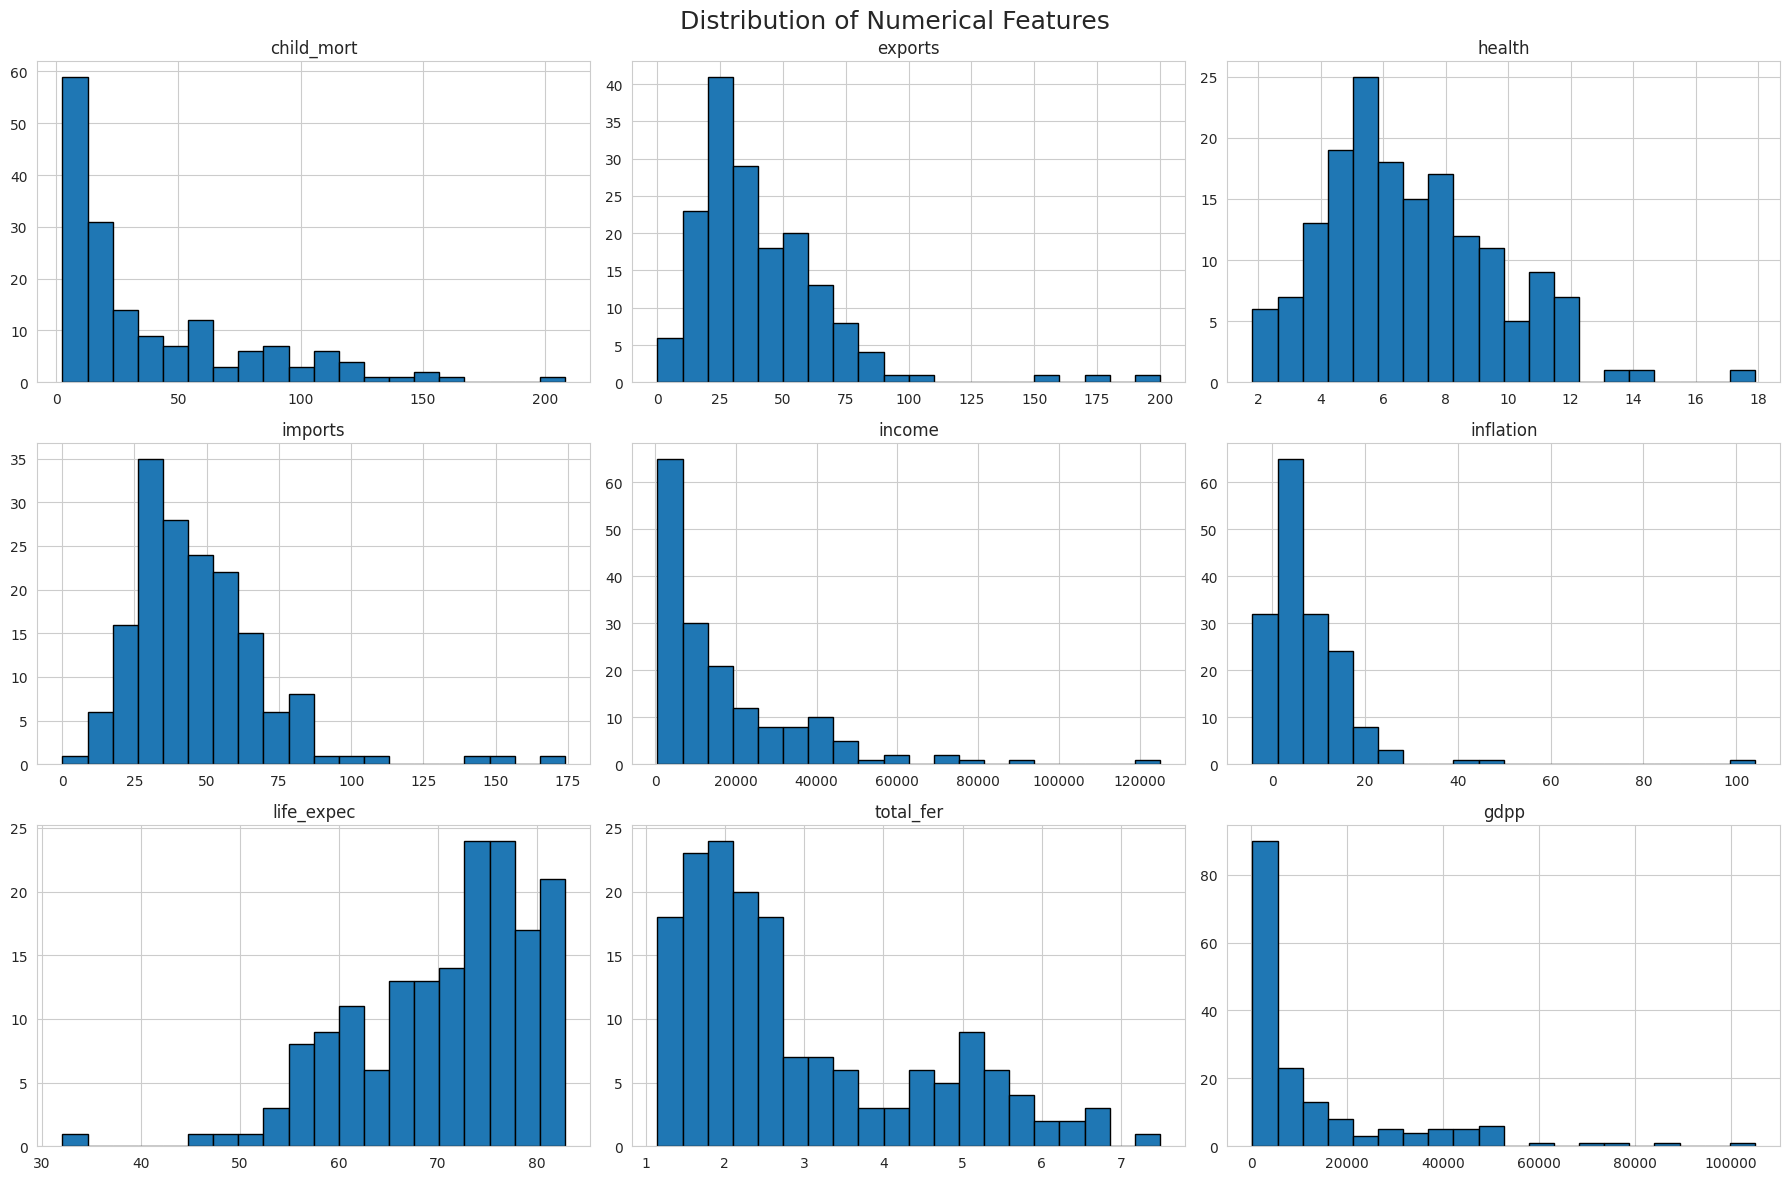

In [ ]:
df[numeric_cols].hist(figsize=(18, 12), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=18)
plt.tight_layout()
plt.show()

### **Observation**

The variables show different ranges and distributions, which indicates that feature scaling will be necessary before clustering. This is important because K-Means relies on distances and can be dominated by features with large numeric scales.

## 📦 **Outlier Detection Using Boxplots** 📦

Boxplots are used to visualize the spread of numerical features and identify potential outliers that may influence clustering performance.

---

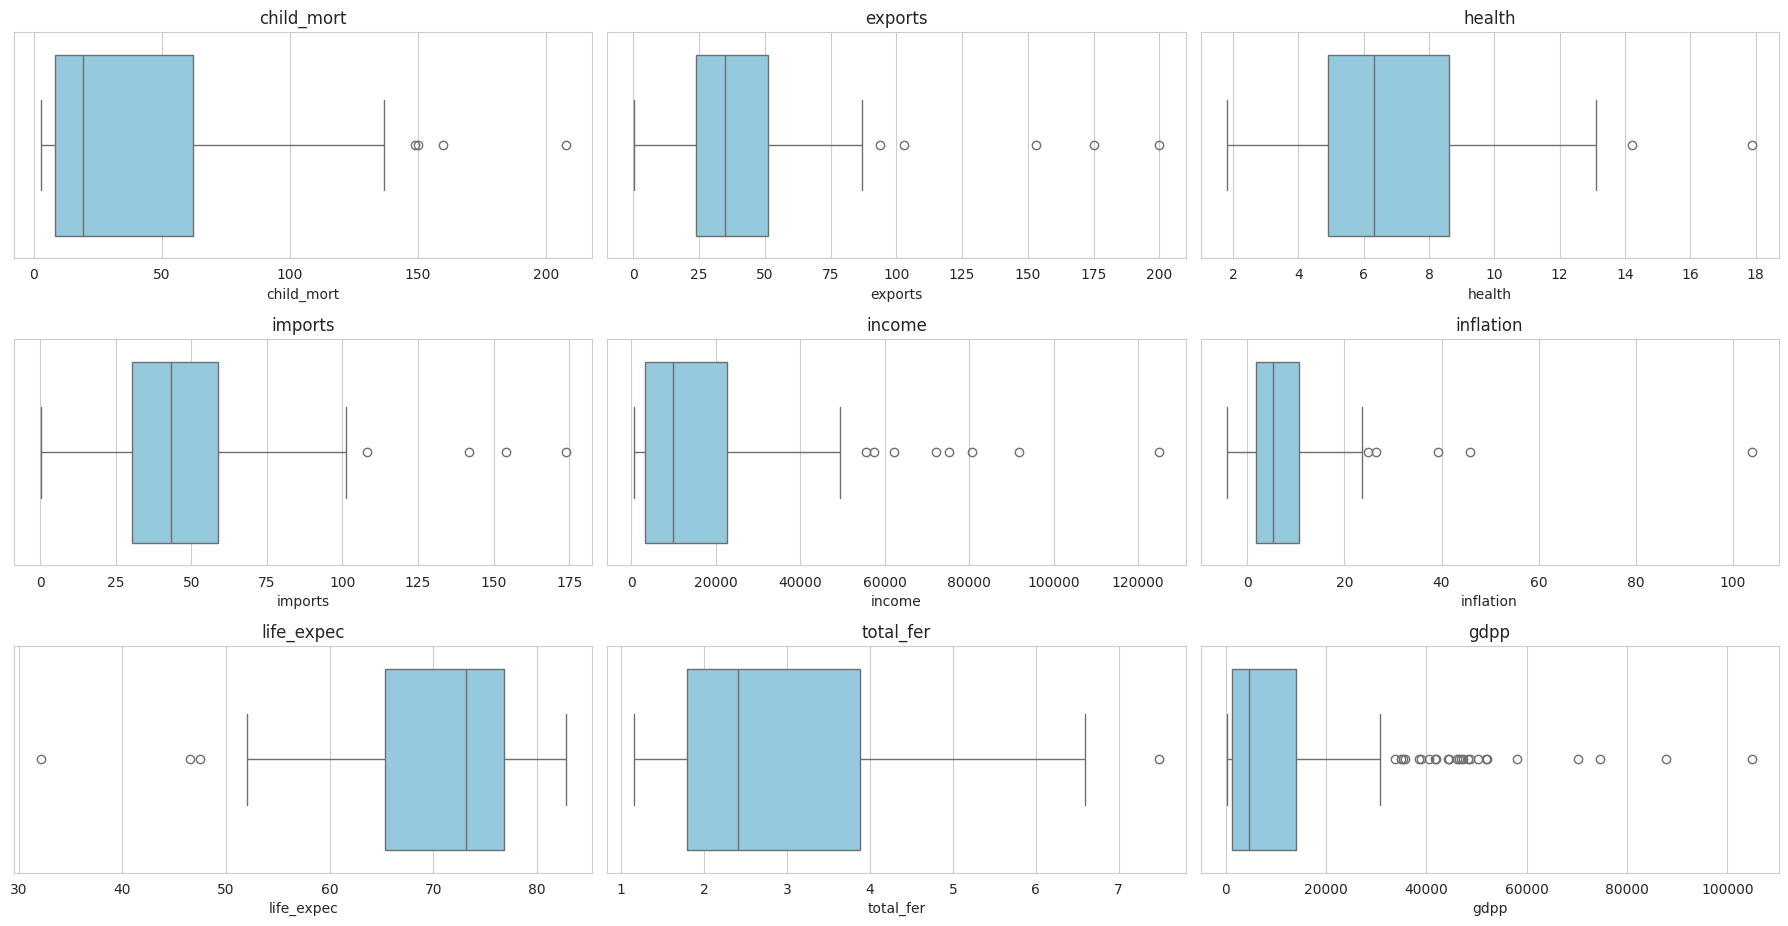

In [ ]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

### **Observation**

Several features contain outliers, which is expected because some countries are significantly richer or poorer than others. These observations are retained because they may be meaningful for identifying high-priority countries.

## 🔥 **Correlation Analysis** 🔥

The correlation heatmap highlights relationships among variables and helps understand how economic and health indicators interact with each other.

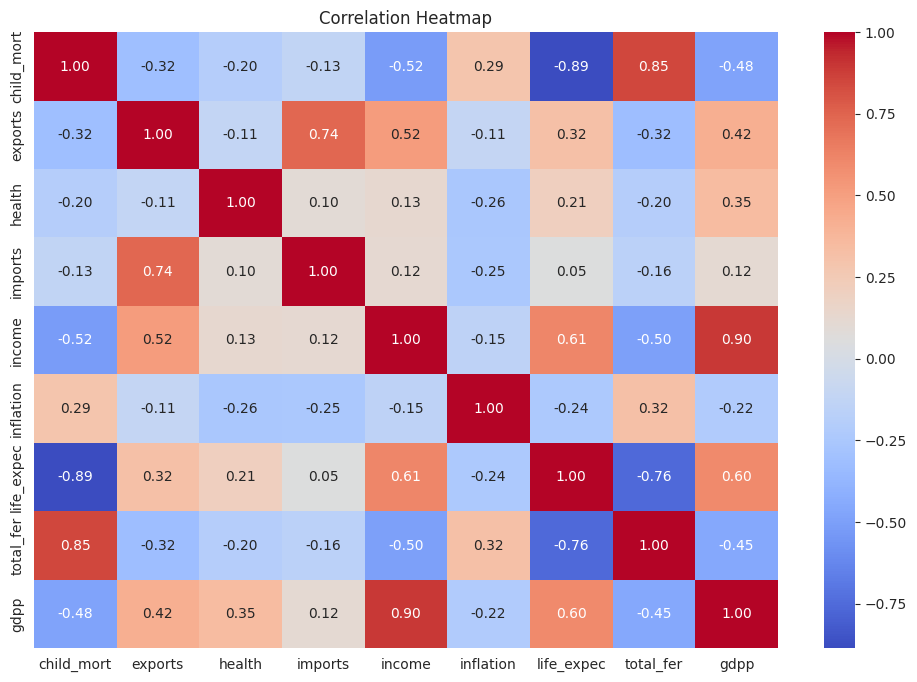

In [ ]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### **Observation**

Some development indicators are positively related, while variables such as child mortality and life expectancy are expected to move in opposite directions across countries. This confirms that the dataset contains meaningful structure for segmentation.

## ⚙️ **Feature Scaling** ⚙️

Feature scaling is performed using StandardScaler to ensure all variables contribute equally during clustering.

In [ ]:
country_names = df['country']
X = df.drop('country', axis=1)

display(X.head())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled_df.head())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 📉 **Elbow Method for Optimal Clusters** 📉

The Elbow Method is used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS).


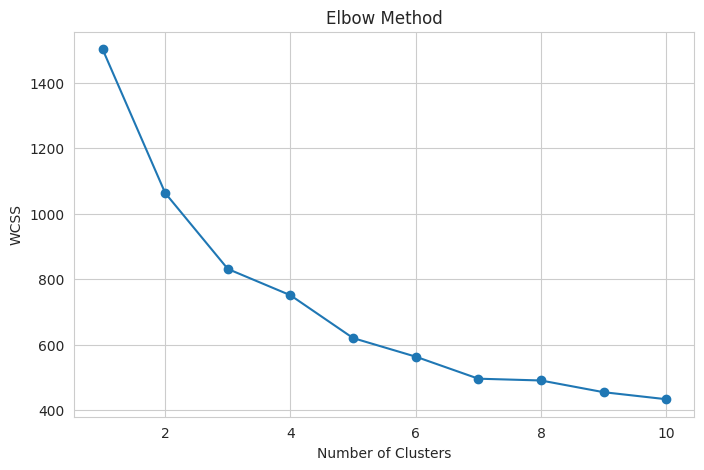

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

### **Observation**

The elbow curve shows a visible bend around **K = 3**, after which the reduction in WCSS becomes more gradual. This suggests that choosing 3 clusters provides a reasonable balance between compactness and simplicity for country segmentation.

## 🎯 **Silhouette Score Analysis** 🎯

Silhouette Scores are calculated to evaluate clustering quality and validate the optimal number of clusters.

---

In [ ]:
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k}: {score:.4f}")

    silhouette_scores.append(score)



K=2: 0.2663
K=3: 0.2856
K=4: 0.2880
K=5: 0.3009
K=6: 0.2357
K=7: 0.2479
K=8: 0.2020
K=9: 0.1923
K=10: 0.1962


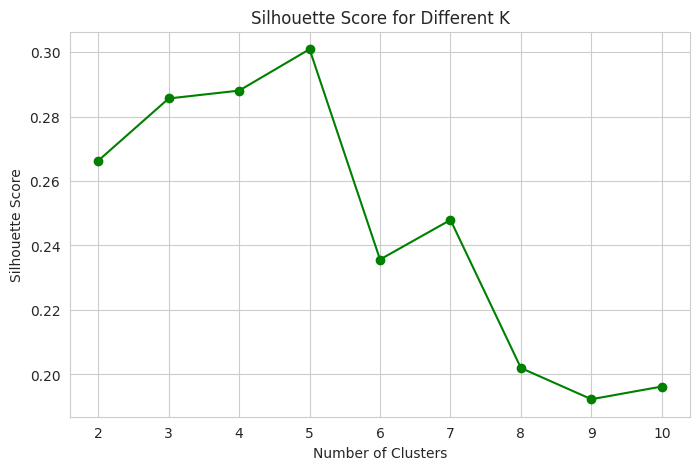

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

### **Observation**

The silhouette trend should be interpreted together with the elbow plot. In this notebook, the final choice of **K = 3** is justified because it gives meaningful separation while also aligning with the elbow method. This makes the clustering solution more reliable for business interpretation.

## 🤖 **K-Means Clustering** 🤖

K-Means clustering is applied to group countries with similar socio-economic characteristics into meaningful clusters.

---

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


## 🔄 **DBSCAN Clustering Comparison** 🔄

DBSCAN is implemented as an alternative clustering technique to compare clustering behavior and identify potential outliers.

---

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64


In [ ]:
print("K-Means Cluster Distribution:")
print(df['Cluster'].value_counts())

print("\nDBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts())

K-Means Cluster Distribution:
Cluster
0    86
2    45
1    36
Name: count, dtype: int64

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


## 📊 **Cluster Distribution Analysis** 📊

This section analyzes how countries are distributed across the generated clusters.

---

In [ ]:
display(df['Cluster'].value_counts().sort_index())

,count
Cluster,
0,86
1,36
2,45


## 🏷️ **Cluster Profiling** 🏷️

Cluster profiling helps understand the characteristics of each cluster by examining average socio-economic and health indicators.

---

In [ ]:
cluster_profile = df.groupby('Cluster')[[
    'child_mort', 'exports', 'health', 'imports',
    'income', 'inflation', 'life_expec', 'total_fer', 'gdpp'
]].mean().round(2)

display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77
1,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
2,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71


## 🔥 **Cluster Profile Heatmap** 🔥

A heatmap is used to compare cluster characteristics and visualize differences across important indicators.

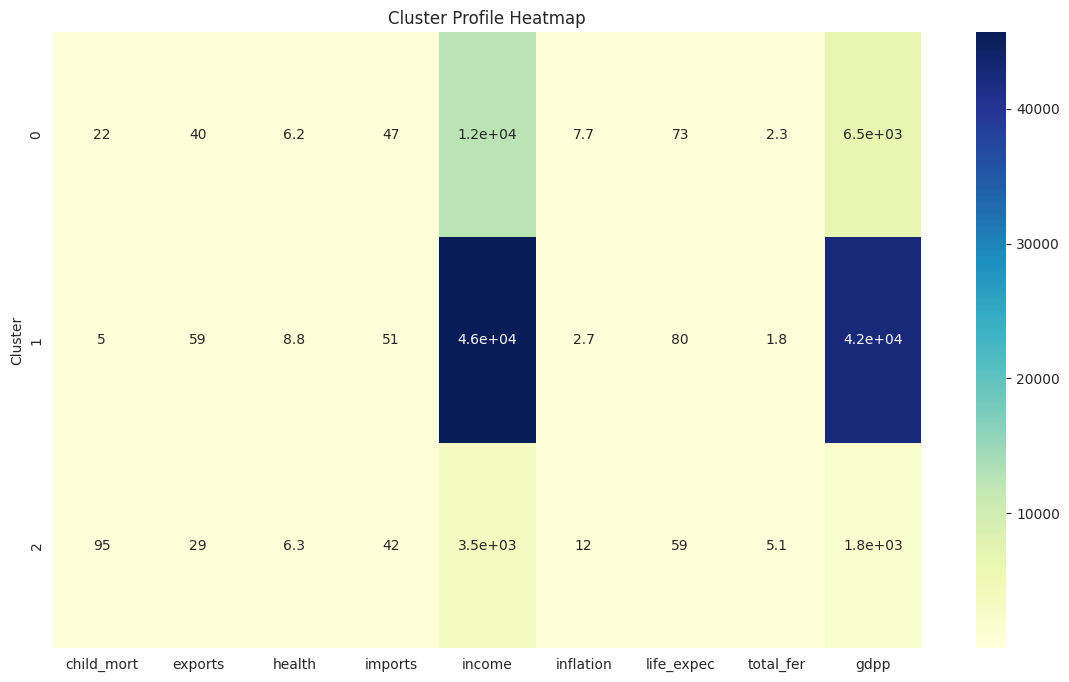

In [ ]:
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profile, annot=True, cmap='YlGnBu')
plt.title('Cluster Profile Heatmap')
plt.show()

### 📌 **Key Observation**

The cluster with the highest child mortality, lowest income, lowest GDP per capita, and lowest life expectancy represents the most vulnerable group of countries. These countries are likely to require priority support from NGOs and development agencies.

## 🎨 **Cluster Visualization Using K-Means** 🎨

Scatter plots are used to visually inspect how countries are grouped across important development indicators.

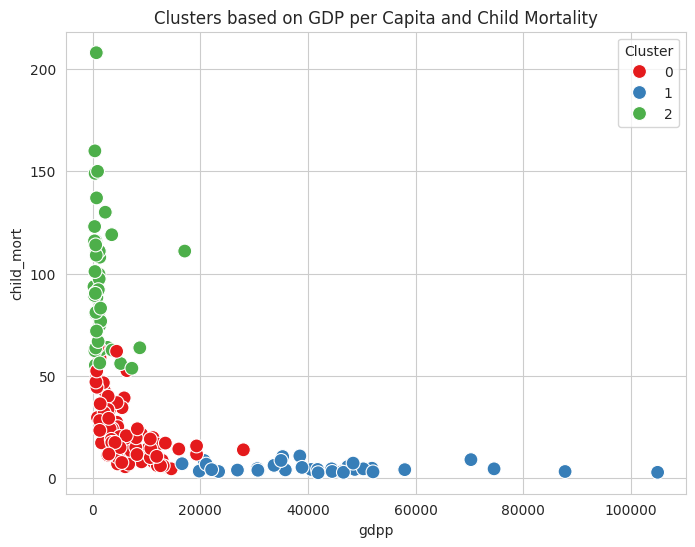

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='gdpp', y='child_mort', hue='Cluster', palette='Set1', s=100)
plt.title('Clusters based on GDP per Capita and Child Mortality')
plt.show()

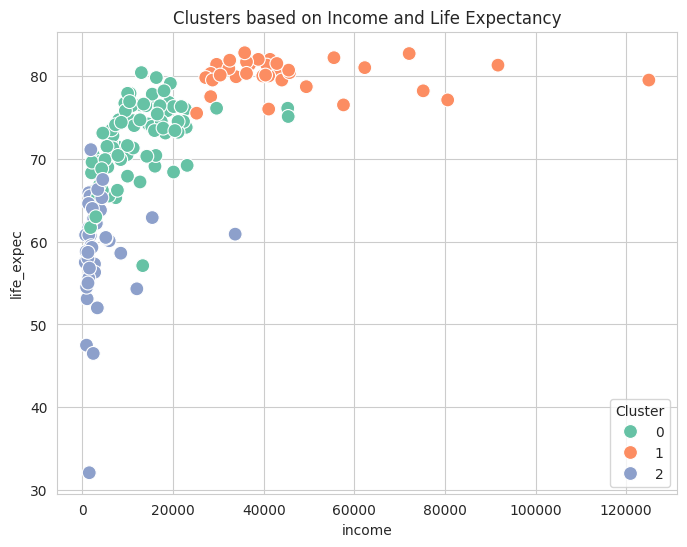

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='income', y='life_expec', hue='Cluster', palette='Set2', s=100)
plt.title('Clusters based on Income and Life Expectancy')
plt.show()

### **Observation**

These visualizations help distinguish the relatively developed countries from the more vulnerable ones. Countries with lower economic indicators and weaker health outcomes are expected to appear in the priority cluster.

## 🧭 **PCA-Based Cluster Visualization** 🧭

Principal Component Analysis (PCA) reduces dimensionality and provides a visual representation of cluster separation.

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']
pca_df['country'] = df['country']

display(pca_df.head())

,PC1,PC2,Cluster,country
0,-2.913025,0.095621,2,Afghanistan
1,0.429911,-0.588156,0,Albania
2,-0.285225,-0.455174,0,Algeria
3,-2.932423,1.695555,2,Angola
4,1.033576,0.136659,0,Antigua and Barbuda


In [ ]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.4595174  0.17181626]
Total Variance Explained: 0.6313336543771411


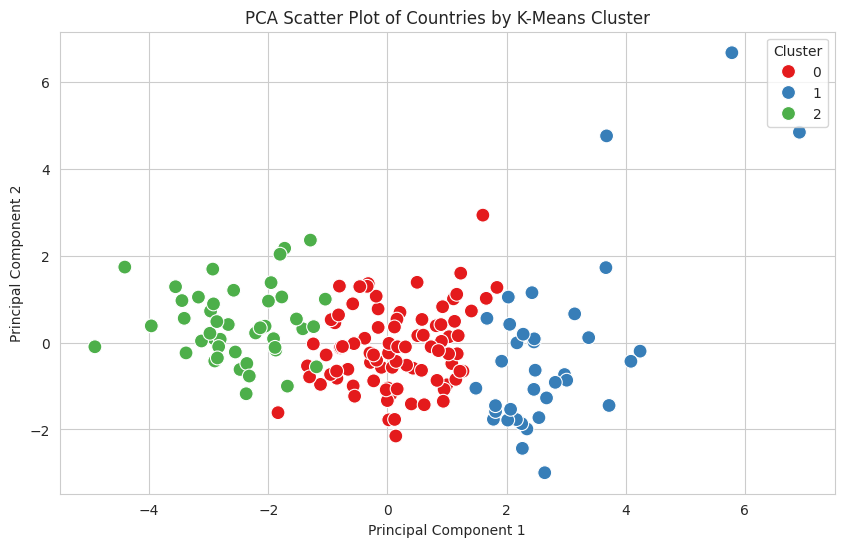

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=100)
plt.title('PCA Scatter Plot of Countries by K-Means Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## 📌 **PCA Interpretation** 📌

The PCA visualization demonstrates that the identified clusters are reasonably separated in the reduced feature space. This confirms that the clustering algorithm successfully captured meaningful patterns within the data.

### 📌 **Key Observation**

The PCA plot provides a compact two-dimensional view of the clustering structure. One cluster appears distinctly separated from the more developed groups, which further supports the validity of the K-Means segmentation.

## 🎯 **Identification of Vulnerable Countries** 🎯

The most vulnerable cluster is identified based on child mortality, income levels, GDP per capita, and life expectancy. Countries belonging to this cluster are considered priority candidates for NGO intervention.

In [ ]:
display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77
1,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
2,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71


### 📌 **Interpretation**

- One cluster represents relatively developed countries with high income, strong GDP per capita, low child mortality, and high life expectancy.
- Another cluster represents moderately developed countries with average socio-economic and health indicators.
- The remaining cluster represents the most vulnerable countries with low income, low GDP per capita, low life expectancy, and high child mortality.

Therefore, the cluster identified as the most vulnerable group should be prioritized for NGO aid allocation.

In [ ]:
priority_cluster = cluster_profile['child_mort'].idxmax()

priority_countries = df[df['Cluster'] == priority_cluster].copy()

display(
    priority_countries[
        ['country', 'income', 'gdpp', 'child_mort', 'life_expec']
    ]
    .sort_values(
        by=['child_mort', 'gdpp'],
        ascending=[False, True]
    )
    .head(10)
)

,country,income,gdpp,child_mort,life_expec
66,Haiti,1500,662,208.0,32.1
132,Sierra Leone,1220,399,160.0,55.0
32,Chad,1930,897,150.0,56.5
31,Central African Republic,888,446,149.0,47.5
97,Mali,1870,708,137.0,59.5
113,Nigeria,5150,2330,130.0,60.5
112,Niger,814,348,123.0,58.8
3,Angola,5900,3530,119.0,60.1
37,"Congo, Dem. Rep.",609,334,116.0,57.5
25,Burkina Faso,1430,575,116.0,57.9


## 🎯 **Cluster Selection Logic** 🎯

The cluster with the highest average child mortality rate was selected as the most vulnerable cluster. Child mortality is a strong indicator of healthcare access, poverty levels, and overall developmental challenges. Therefore, countries belonging to this cluster are considered priority candidates for NGO intervention.

## 🌍 **NGO Aid Recommendations** 🌍

Based on cluster profiling, the most vulnerable countries should receive priority support in healthcare, education, sanitation, nutrition, and economic development initiatives.

## 📝 **Key Insights & Conclusion** 📝

### **Key Findings**

- Countries were successfully grouped into meaningful socio-economic clusters.
- K-Means clustering provided clear segmentation.
- PCA visualization validated cluster separation.
- Vulnerable countries were identified using cluster profiling.

### **Conclusion**

The project demonstrates how machine learning can support evidence-based decision making for international aid organizations and policymakers. The clustering approach effectively identifies countries requiring focused developmental assistance.

---

## 🚀 **Future Scope** 🚀

- Explore Hierarchical Clustering techniques.
- Apply advanced visualization methods such as t-SNE and UMAP.
- Include additional socio-economic indicators.
- Develop interactive dashboards for policymakers and NGOs.
- Perform temporal analysis using multi-year datasets.

---

## ✅ **Project Completion Summary** ✅

This project successfully applied Data Cleaning, Exploratory Data Analysis, Feature Scaling, K-Means Clustering, DBSCAN, PCA, and Cluster Profiling to identify vulnerable countries for NGO aid allocation.

### **Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

### **Techniques Used**
- Data Cleaning
- EDA
- Feature Scaling
- K-Means Clustering
- DBSCAN
- PCA
- Cluster Profiling

---
**End of Project**